## Download Data & Data Cleaning

In [1]:
import yfinance as yf
import pandas as pd

In [2]:
start_date='2005-01-01'
end_date = '2025-12-31'
tickers = {
        'SP500': '^GSPC', 
        'VIX': '^VIX', 
        'TNX': '^TNX'  # 10Y Treasury
}
market_data = yf.download(list(tickers.values()), start=start_date, end=end_date, auto_adjust = False)

[*********************100%***********************]  3 of 3 completed


In [3]:
market_data.head()

Price         Adj Close                      Close                       High  \
Ticker            ^GSPC   ^TNX   ^VIX        ^GSPC   ^TNX   ^VIX        ^GSPC   
Date                                                                            
2005-01-03  1202.079956  4.220  14.08  1202.079956  4.220  14.08  1217.800049   
2005-01-04  1188.050049  4.283  13.98  1188.050049  4.283  13.98  1205.839966   
2005-01-05  1183.739990  4.277  14.09  1183.739990  4.277  14.09  1192.729980   
2005-01-06  1187.890015  4.272  13.58  1187.890015  4.272  13.58  1191.630005   
2005-01-07  1186.189941  4.285  13.49  1186.189941  4.285  13.49  1192.199951   

Price                             Low                       Open         \
Ticker       ^TNX   ^VIX        ^GSPC   ^TNX   ^VIX        ^GSPC   ^TNX   
Date                                                                      
2005-01-03  4.270  14.23  1200.319946  4.203  13.25  1211.920044  4.257   
2005-01-04  4.307  14.45  1185.390015  4.197  13.93  1202.079956  4.212   
2005-01-05  4.304  14.09  1183.719971  4.255  13.26  1188.050049  4.298   
2005-01-06  4.298  14.09  1183.270020  4.257  13.33  1183.739990  4.288   
2005-01-07  4.313  13.51  1182.160034  4.148  12.94  1187.890015  4.255   

Price                  Volume            
Ticker       ^VIX       ^GSPC ^TNX ^VIX  
Date                                     
2005-01-03  13.39  1510800000  0.0    0  
2005-01-04  14.01  1721000000  0.0    0  
2005-01-05  13.98  1738900000  0.0    0  
2005-01-06  14.09  1569100000  0.0    0  
2005-01-07  13.47  1477900000  0.0    0

In [4]:
raw_data = market_data['Adj Close'].copy()
raw_data['Volume'] = market_data[('Volume', '^GSPC')]
raw_data.rename(columns={'^GSPC':'Close','^VIX':'VIX','^TNX':'TBR'}, inplace = True)
raw_data.columns.name= None
raw_data.head()

,Close,TBR,VIX,Volume
Date,,,,
2005-01-03,1202.079956,4.220,14.08,1510800000
2005-01-04,1188.050049,4.283,13.98,1721000000
2005-01-05,1183.739990,4.277,14.09,1738900000
2005-01-06,1187.890015,4.272,13.58,1569100000
2005-01-07,1186.189941,4.285,13.49,1477900000


In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5282 entries, 2005-01-03 to 2025-12-30
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   5282 non-null   float64
 1   TBR     5277 non-null   float64
 2   VIX     5282 non-null   float64
 3   Volume  5282 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 206.3 KB


In [6]:
CDSpread = pd.read_csv('RawData/BAMLH0A0HYM2.csv',parse_dates=['observation_date'])
CDSpread.rename(columns = {'observation_date' : 'Date', 'BAMLH0A0HYM2':'OAS'}, inplace = True)
CDSpread.set_index('Date', inplace=True)
CDSpread.dropna(inplace=True)
CDSpread.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5483 entries, 2005-01-03 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   OAS     5483 non-null   float64
dtypes: float64(1)
memory usage: 85.7 KB


In [7]:
raw_data = raw_data.merge(CDSpread, on = 'Date', how='left')
raw_data.head(5)

,Close,TBR,VIX,Volume,OAS
Date,,,,,
2005-01-03,1202.079956,4.220,14.08,1510800000,3.06
2005-01-04,1188.050049,4.283,13.98,1721000000,2.97
2005-01-05,1183.739990,4.277,14.09,1738900000,3.04
2005-01-06,1187.890015,4.272,13.58,1569100000,3.09
2005-01-07,1186.189941,4.285,13.49,1477900000,3.07


In [8]:
raw_data.dropna(inplace = True)
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5275 entries, 2005-01-03 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   5275 non-null   float64
 1   TBR     5275 non-null   float64
 2   VIX     5275 non-null   float64
 3   Volume  5275 non-null   int64  
 4   OAS     5275 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 247.3 KB


In [9]:
file_name = 'sp500_market_features_2005_2025.csv'
raw_data.to_csv('RawData/'+file_name, index = True)

## Visualization & Engineering

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from sklearn.preprocessing import StandardScaler
import joblib

In [3]:
raw_data = pd.read_csv('RawData/sp500_market_features_2005_2025.csv', index_col = 0, parse_dates=True)
raw_data['Volume'] = raw_data['Volume'].replace(0, np.nan)
raw_data['Volume'] = raw_data['Volume'].ffill()
raw_data.head()

,Close,TBR,VIX,Volume,OAS
Date,,,,,
2005-01-03,1202.079956,4.220,14.08,1.510800e+09,3.06
2005-01-04,1188.050049,4.283,13.98,1.721000e+09,2.97
2005-01-05,1183.739990,4.277,14.09,1.738900e+09,3.04
2005-01-06,1187.890015,4.272,13.58,1.569100e+09,3.09
2005-01-07,1186.189941,4.285,13.49,1.477900e+09,3.07


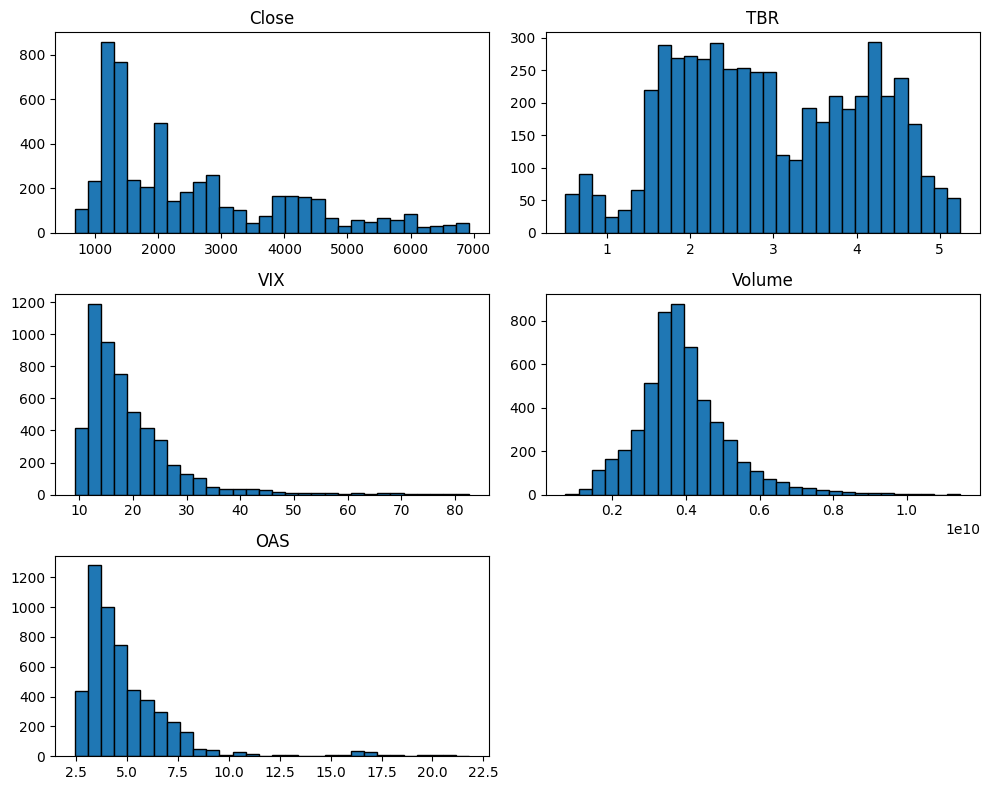

In [4]:
raw_data.hist(bins=30, figsize=(10, 8), edgecolor='black', grid=False)

plt.tight_layout()
plt.show()

In [5]:
prepared_data = pd.DataFrame()
prepared_data['RR'] = np.log(raw_data['Close'] / raw_data['Close'].shift(1))    #return rate
prepared_data['VCR'] = np.log(raw_data['Volume'] / raw_data['Volume'].shift(1)) #Volume Change rate
prepared_data['VIXD'] = raw_data['VIX'].diff()
prepared_data['TBRD'] = raw_data['TBR'].diff()
prepared_data['OASD'] = raw_data['OAS'].diff()
prepared_data.dropna(inplace=True)
prepared_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5274 entries, 2005-01-04 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RR      5274 non-null   float64
 1   VCR     5274 non-null   float64
 2   VIXD    5274 non-null   float64
 3   TBRD    5274 non-null   float64
 4   OASD    5274 non-null   float64
dtypes: float64(5)
memory usage: 247.2 KB


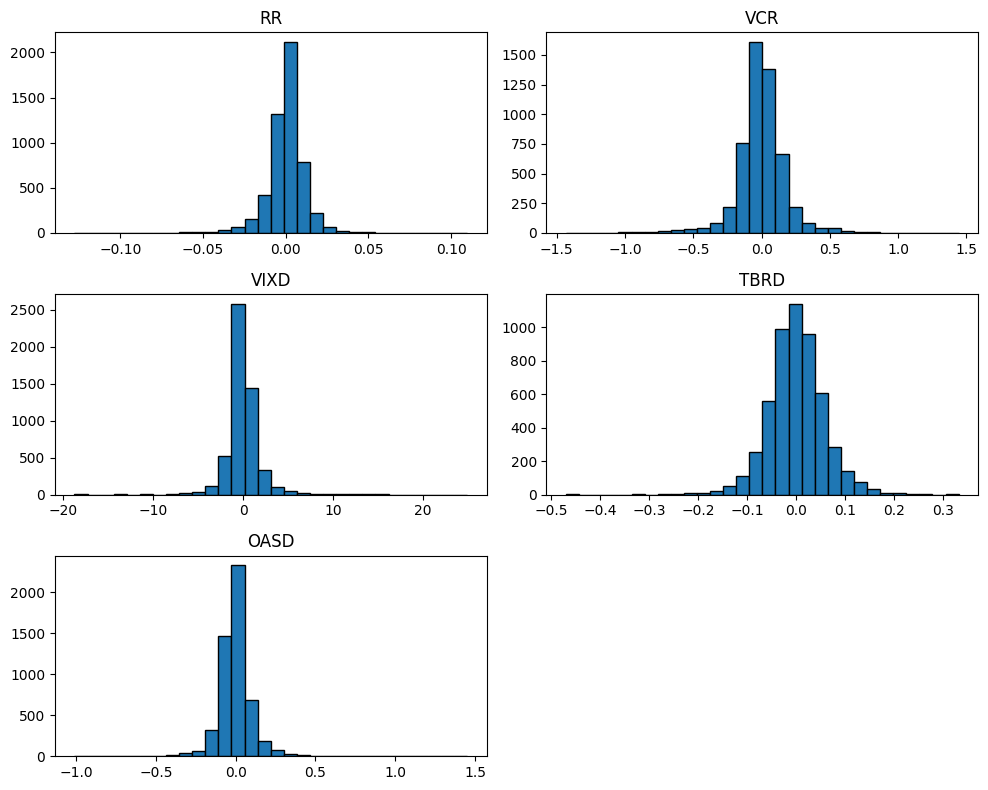

In [6]:
prepared_data.hist(bins=30, figsize=(10, 8), edgecolor='black', grid=False)

plt.tight_layout()
plt.show()

In [7]:
prepared_data.describe()

,RR,VCR,VIXD,TBRD,OASD
count,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000
mean,0.000331,0.000149,0.000047,-0.000017,-0.000042
std,0.012095,0.183131,1.915505,0.056539,0.108701
min,-0.127652,-1.431939,-18.710003,-0.470000,-1.010000
25%,-0.004062,-0.079388,-0.730000,-0.033000,-0.050000
50%,0.000738,-0.002215,-0.094999,-0.001000,0.000000
75%,0.005706,0.082730,0.570000,0.033000,0.040000
max,0.109572,1.443290,24.860001,0.332000,1.450000


In [8]:
train_arr_data = prepared_data[:'2021-12-31'].values
cv_test_arr_data = prepared_data['2022-01-01':].values
scaler = StandardScaler()

# Only standardized train data.
train_arr_data = scaler.fit_transform(train_arr_data)
cv_test_arr_data = scaler.transform(cv_test_arr_data)

Arr_data = np.concat((train_arr_data, cv_test_arr_data), axis = 0)
scaled_data = pd.DataFrame(Arr_data, index = prepared_data.index, columns=prepared_data.columns)
scaled_data.describe()

,RR,VCR,VIXD,TBRD,OASD
count,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000
mean,0.000715,0.000080,-0.000353,0.011439,-0.000458
std,0.983851,0.993264,0.984122,1.048552,0.973904
min,-10.409674,-7.767266,-9.612943,-8.704632,-9.049131
25%,-0.356659,-0.431309,-0.375427,-0.600246,-0.448056
50%,0.033773,-0.012742,-0.049185,-0.006788,-0.000084
75%,0.437899,0.447986,0.292469,0.623757,0.358294
max,8.886541,7.827375,12.771848,6.168864,12.991122


In [9]:
file_name = 'sp500_scaled_features.pkl'
scaled_data.to_pickle('PreparedData/'+file_name)

joblib.dump(scaler, 'PreparedData/sp500_scaler.pkl')

['PreparedData/sp500_scaler.pkl']

## Final Demonstrate

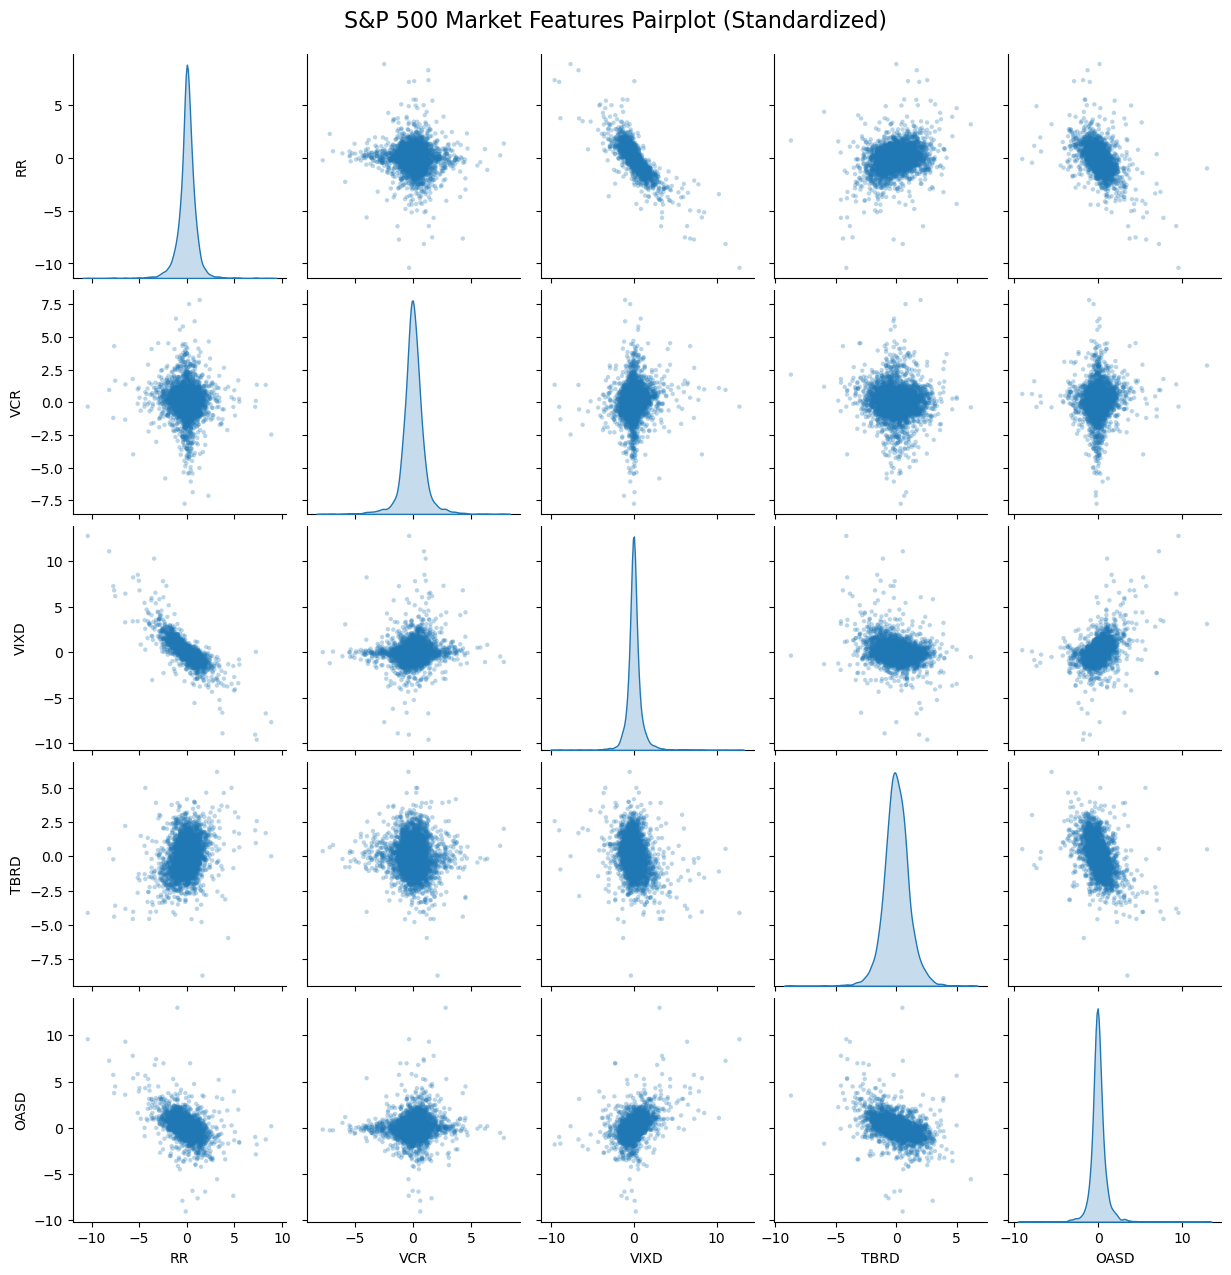

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

scaled_data = pd.read_pickle('PreparedData/sp500_scaled_features.pkl')

# 1. 绘制 Pairplot
# kind='scatter': 散点图，用于观察两个变量的关系
# diag_kind='kde': 核密度估计，用于观察单个变量的分布形状
# alpha=0.3: 设置透明度，因为金融数据点很密集，透明度能让你看清哪里是“高密度区”
g = sns.pairplot(scaled_data, diag_kind='kde', 
                 plot_kws={'alpha': 0.3, 's': 10, 'edgecolor': 'none'},
                 height=2.5)

# 2. 调整标题位置
g.fig.suptitle('S&P 500 Market Features Pairplot (Standardized)', y=1.02, fontsize=16)

plt.show()

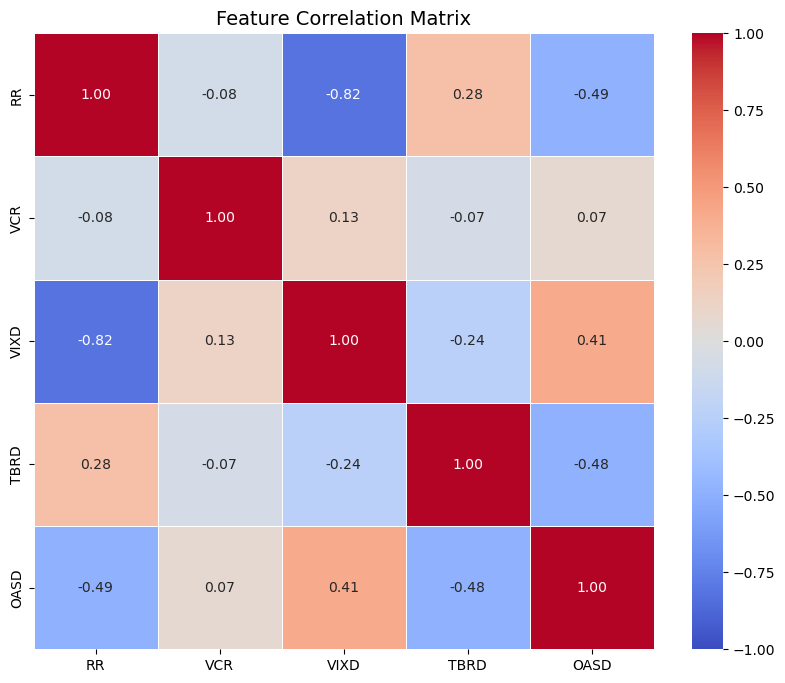

In [2]:
plt.figure(figsize=(10, 8))

# 计算皮尔逊相关系数
corr_matrix = scaled_data.corr()

# 绘制热力图
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Feature Correlation Matrix', fontsize=14)
plt.show()